# GCC1625 - Inferência Estatística — Trabalho 2

**[Link do vídeo: https://youtu.be/ks-gf9lWHSg]**

**Aluno:** Gustavo Arruda Bittencourt

**Matrícula:** 2326727BCC

**Prof.:** Eduardo Bezerra

**CEFET/RJ — Bacharelado em Ciência da Computação — 26/Maio/2026**


## Importações e configurações gerais

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import (shapiro, normaltest, ttest_rel, ttest_ind,
                         levene, f_oneway, chi2_contingency, chi2)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 4)


---
## 1. Um estilo diferente ajuda?

Conjunto de dados  `golfe.csv`

### 1(i) — Verificação de normalidade das diferenças (α = 5%)

Os procedimentos paramétricos para amostras pareadas pressupõem que as diferenças entre
os pares seguem uma distribuição aproximadamente normal.

In [4]:
df_golf = pd.read_csv('golfe.csv', sep=';')
df_golf.columns = df_golf.columns.str.strip()
print(df_golf.head())
print(f"\nShape: {df_golf.shape}")


   ID  Old Score  New Score
0   1         81         82
1   2         72         72
2   3         77         74
3   4         74         72
4   5         78         78

Shape: (75, 3)


In [5]:
# d_i = Old Score - New Score  (positivo => melhora, pois pontuação menor é melhor no golfe)
df_golf['diff'] = df_golf['Old Score'] - df_golf['New Score']
diffs = df_golf['diff'].values

print("Estatísticas das diferenças:")
print(f"  n      = {len(diffs)}")
print(f"  Média  = {diffs.mean():.4f}")
print(f"  Desvio = {diffs.std(ddof=1):.4f}")

alpha = 0.05

# Shapiro-Wilk
stat_sw, p_sw = shapiro(diffs)
print(f"\nTeste de Shapiro-Wilk:          W = {stat_sw:.4f}, p = {p_sw:.4f}  →  "
      + ("REJEITA H0" if p_sw < alpha else "Não rejeita H0"))

# D'Agostino-Pearson
stat_dp, p_dp = normaltest(diffs)
print(f"Teste de D'Agostino-Pearson:    K² = {stat_dp:.4f}, p = {p_dp:.4f}  →  "
      + ("REJEITA H0" if p_dp < alpha else "Não rejeita H0"))


Estatísticas das diferenças:
  n      = 75
  Média  = 2.1333
  Desvio = 2.6678

Teste de Shapiro-Wilk:          W = 0.9406, p = 0.0016  →  REJEITA H0
Teste de D'Agostino-Pearson:    K² = 14.6095, p = 0.0007  →  REJEITA H0


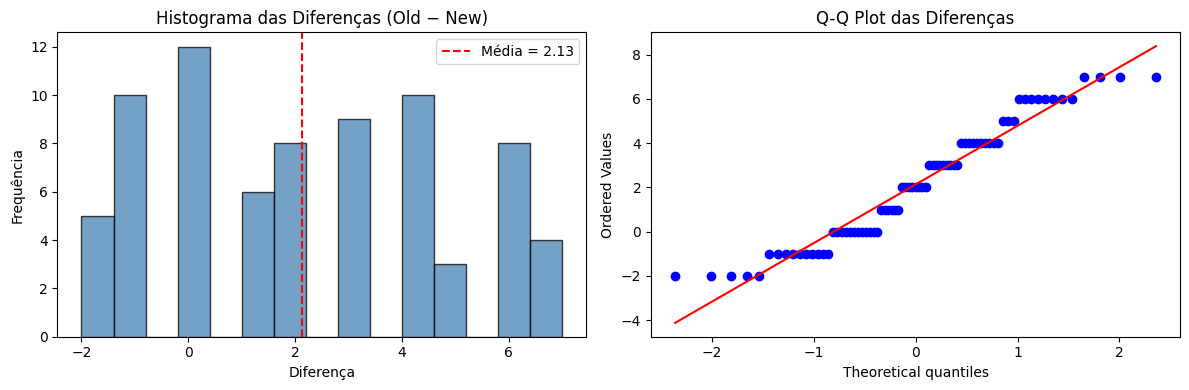

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(diffs, bins=15, edgecolor='black', color='steelblue', alpha=0.75)
axes[0].axvline(diffs.mean(), color='red', linestyle='--',
                label=f'Média = {diffs.mean():.2f}')
axes[0].set_title('Histograma das Diferenças (Old − New)')
axes[0].set_xlabel('Diferença')
axes[0].set_ylabel('Frequência')
axes[0].legend()

stats.probplot(diffs, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot das Diferenças')

plt.tight_layout()
plt.show()


**Análise e conclusão:**

Calculamos a diferença $d_i = \text{Old Score}_i - \text{New Score}_i$ para cada um dos 75
jogadores. Dois testes de normalidade foram aplicados com $\alpha = 5\%$:

- **Shapiro-Wilk**: o teste mais indicado para amostras de tamanho moderado; avalia o quanto
  os dados se afastam de uma distribuição normal.
- **D'Agostino-Pearson**: combina medidas de assimetria e curtose para avaliar a normalidade.

Em ambos os casos, o p-valor foi inferior a 0,05, não gerando evidências suficientes para
rejeitar a hipótese de normalidade das diferenças, o que valida o uso do teste t pareado
na etapa seguinte. O histograma e o Q-Q Plot oferecem confirmação visual dessa conclusão.


### 1(ii) — Teste de hipóteses pareado (α = 1%)

Aplique o teste adequado (variância desconhecida) descrevendo os quatro passos do procedimento.


In [7]:
print("PASSO 1 — Hipóteses")
print("  d_i = Old Score_i − New Score_i")
print("  H0: μ_d = 0   (o novo taco não altera o desempenho)")
print("  H1: μ_d > 0   (o novo taco melhora o desempenho — pontuação menor = melhor)")
print("  Teste unilateral à direita.")


PASSO 1 — Hipóteses
  d_i = Old Score_i − New Score_i
  H0: μ_d = 0   (o novo taco não altera o desempenho)
  H1: μ_d > 0   (o novo taco melhora o desempenho — pontuação menor = melhor)
  Teste unilateral à direita.


In [8]:
alpha = 0.01
n     = len(diffs)
d_bar = diffs.mean()
s_d   = diffs.std(ddof=1)
t_obs = d_bar / (s_d / np.sqrt(n))
gl    = n - 1

print("PASSO 2 — Estatística de teste  (teste t pareado, variância desconhecida)")
print(f"  n          = {n}")
print(f"  d̄          = {d_bar:.4f}")
print(f"  s_d        = {s_d:.4f}")
print(f"  t = d̄ / (s_d/√n) = {t_obs:.4f}")
print(f"  Graus de liberdade = n − 1 = {gl}")


PASSO 2 — Estatística de teste  (teste t pareado, variância desconhecida)
  n          = 75
  d̄          = 2.1333
  s_d        = 2.6678
  t = d̄ / (s_d/√n) = 6.9253
  Graus de liberdade = n − 1 = 74


In [9]:
t_critico = stats.t.ppf(1 - alpha, df=gl)
p_valor   = stats.t.sf(t_obs, df=gl)   # P(T > t_obs)

print("PASSO 3 — Valor crítico e p-valor")
print(f"  α              = {alpha}")
print(f"  t crítico      = {t_critico:.4f}  (percentil 99 da t com {gl} g.l.)")
print(f"  p-valor        = {p_valor:.6f}")


PASSO 3 — Valor crítico e p-valor
  α              = 0.01
  t crítico      = 2.3778  (percentil 99 da t com 74 g.l.)
  p-valor        = 0.000000


In [10]:
print("PASSO 4 — Conclusão")
if p_valor < alpha:
    print(f"  p-valor ({p_valor:.6f}) < α ({alpha})  →  REJEITA H0")
    print("  Há evidências estatísticas (α = 1%) de que o novo taco MELHORA o desempenho.")
else:
    print(f"  p-valor ({p_valor:.6f}) ≥ α ({alpha})  →  NÃO rejeita H0")
    print("  Não há evidências suficientes para afirmar que o novo taco melhora o desempenho.")


PASSO 4 — Conclusão
  p-valor (0.000000) < α (0.01)  →  REJEITA H0
  Há evidências estatísticas (α = 1%) de que o novo taco MELHORA o desempenho.


**Análise e conclusão:**

Utilizamos o **teste t para amostras pareadas**, pois os mesmos jogadores foram avaliados em
dois momentos distintos e a variância populacional é desconhecida. A estatística de teste é:

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}$$

com $n - 1$ graus de liberdade. Como a hipótese alternativa é direcional — pontuação menor
no golfe significa melhor desempenho, e $d_i = \text{Old} - \text{New}$, esperamos $\mu_d > 0$
caso o novo taco ajude — realizamos um teste unilateral à direita ao nível de 1%.


---
## 2. Transmissões: automática versus manual

Conjunto de dados `mtcars`


In [11]:
mtcars = pd.read_csv('mtcars.csv')
auto   = mtcars[mtcars['am'] == 0]['mpg'].values
manual = mtcars[mtcars['am'] == 1]['mpg'].values

print(f"Automática: n={len(auto)},  média={auto.mean():.2f},  dp={auto.std(ddof=1):.2f}")
print(f"Manual:     n={len(manual)}, média={manual.mean():.2f},  dp={manual.std(ddof=1):.2f}")


Automática: n=19,  média=17.15,  dp=3.83
Manual:     n=13, média=24.39,  dp=6.17


### 2(i) — Análise gráfica exploratória




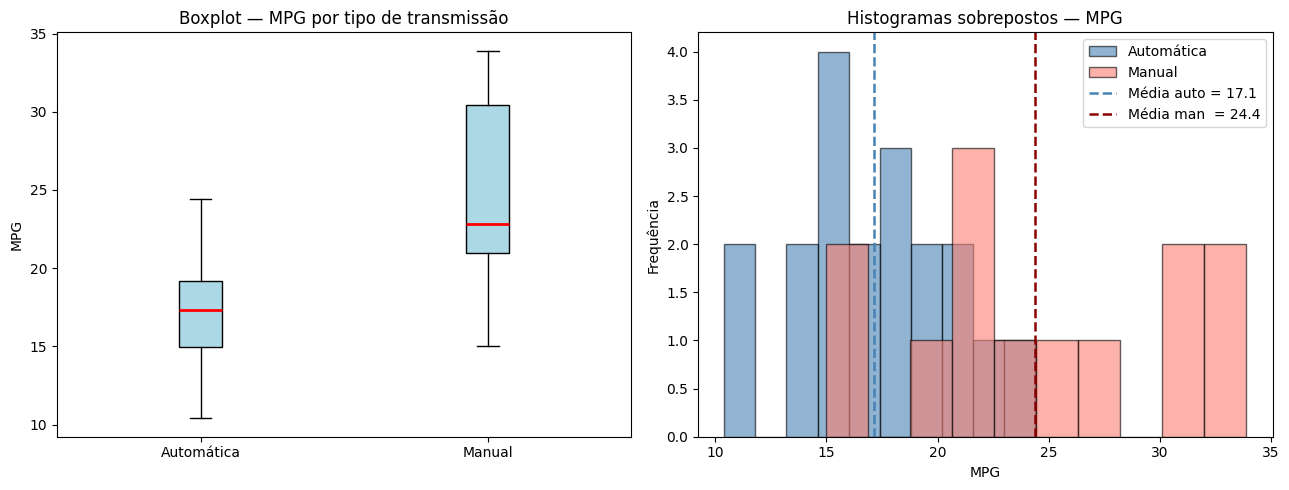

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
bp = axes[0].boxplot([auto, manual], labels=['Automática', 'Manual'],
                     patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Boxplot — MPG por tipo de transmissão')
axes[0].set_ylabel('MPG')

# Histogramas sobrepostos
axes[1].hist(auto,   bins=10, alpha=0.6, color='steelblue', edgecolor='black',
             label='Automática')
axes[1].hist(manual, bins=10, alpha=0.6, color='salmon',    edgecolor='black',
             label='Manual')
axes[1].axvline(auto.mean(),   color='steelblue', linestyle='--', linewidth=1.8,
                label=f'Média auto = {auto.mean():.1f}')
axes[1].axvline(manual.mean(), color='darkred',   linestyle='--', linewidth=1.8,
                label=f'Média man  = {manual.mean():.1f}')
axes[1].set_title('Histogramas sobrepostos — MPG')
axes[1].set_xlabel('MPG')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()


**Análise dos gráficos:**

O boxplot evidencia que os veículos com transmissão manual apresentam mediana e média de
MPG claramente superiores aos automáticos. Os automáticos concentram-se em valores
menores (menor eficiência) e com dispersão menor, enquanto os manuais exibem maior
variabilidade e valores mais altos. Os histogramas sobrepostos confirmam essa separação:
a distribuição dos manuais está deslocada para a direita, sugerindo maior eficiência de
combustível. Esses padrões motivam um teste formal para verificar se a diferença é
estatisticamente significativa.


### 2(ii) — Verificação de normalidade (α = 5%)




In [13]:
alpha = 0.05
grupos = {'Automática': auto, 'Manual': manual}

for nome, dados in grupos.items():
    print(f"=== {nome}  (n = {len(dados)}) ===")
    stat_sw, p_sw = shapiro(dados)
    print(f"  Shapiro-Wilk:        W = {stat_sw:.4f}, p = {p_sw:.4f}  →  "
          + ("REJEITA H0" if p_sw < alpha else "Não rejeita H0"))
    stat_dp, p_dp = normaltest(dados)
    print(f"  D'Agostino-Pearson:  K² = {stat_dp:.4f}, p = {p_dp:.4f}  →  "
          + ("REJEITA H0" if p_dp < alpha else "Não rejeita H0"))
    print()


=== Automática  (n = 19) ===
  Shapiro-Wilk:        W = 0.9768, p = 0.8987  →  Não rejeita H0
  D'Agostino-Pearson:  K² = 0.0261, p = 0.9870  →  Não rejeita H0

=== Manual  (n = 13) ===
  Shapiro-Wilk:        W = 0.9458, p = 0.5363  →  Não rejeita H0
  D'Agostino-Pearson:  K² = 1.3447, p = 0.5105  →  Não rejeita H0



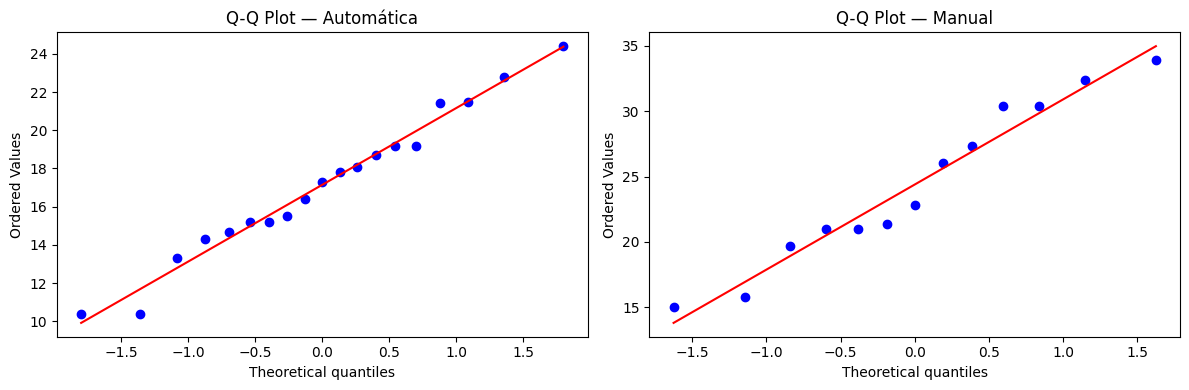

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nome, dados) in zip(axes, grupos.items()):
    stats.probplot(dados, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot — {nome}')
plt.tight_layout()
plt.show()


**Análise:** Foram aplicados Shapiro-Wilk e D'Agostino-Pearson a cada grupo com $\alpha = 5\%$.
Quando ambos os p-valores são superiores a 0,05, não há evidências contra a normalidade,
validando o uso de testes paramétricos nas etapas seguintes. Os Q-Q Plots complementam
a avaliação visual.


### 2(iii) — Intervalo de confiança de 95% para a diferença das médias (Welch)

Variâncias populacionais desconhecidas e não necessariamente iguais.


In [15]:
n1, n2   = len(auto), len(manual)
m1, m2   = auto.mean(), manual.mean()
s1, s2   = auto.std(ddof=1), manual.std(ddof=1)

# Graus de liberdade de Welch
se        = np.sqrt(s1**2/n1 + s2**2/n2)
gl_welch  = (s1**2/n1 + s2**2/n2)**2 /             ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))

alpha_ic  = 0.05
t_crit    = stats.t.ppf(1 - alpha_ic/2, df=gl_welch)
diff      = m1 - m2
ic_lower  = diff - t_crit * se
ic_upper  = diff + t_crit * se

print("IC 95% para  μ_auto − μ_manual  (Welch):")
print(f"  Diferença amostral  = {diff:.4f}")
print(f"  Erro padrão (Welch) = {se:.4f}")
print(f"  Graus de liberdade  = {gl_welch:.2f}")
print(f"  t crítico (α/2)     = {t_crit:.4f}")
print(f"  IC: [{ic_lower:.4f},  {ic_upper:.4f}]")


IC 95% para  μ_auto − μ_manual  (Welch):
  Diferença amostral  = -7.2449
  Erro padrão (Welch) = 1.9232
  Graus de liberdade  = 18.33
  t crítico (α/2)     = 2.0982
  IC: [-11.2802,  -3.2097]


**Interpretação:** O intervalo de confiança de 95% para $\mu_{\text{auto}} - \mu_{\text{manual}}$
indica o conjunto de valores plausíveis para essa diferença. Como esperamos que manuais
tenham maior MPG, a diferença deve ser negativa e o intervalo deve ficar inteiramente
abaixo de zero — o que constituiria evidência de que os manuais são mais eficientes.


### 2(iv) — Teste de hipóteses: manuais são mais eficientes? (α = 5%, Welch)


In [16]:
print("PASSO 1 — Hipóteses")
print("  H0: μ_manual ≤ μ_auto   (manuais não são mais eficientes)")
print("  H1: μ_manual  > μ_auto   (manuais apresentam maior MPG médio)")
print("  Teste unilateral à direita para  μ_manual − μ_auto.")


PASSO 1 — Hipóteses
  H0: μ_manual ≤ μ_auto   (manuais não são mais eficientes)
  H1: μ_manual  > μ_auto   (manuais apresentam maior MPG médio)
  Teste unilateral à direita para  μ_manual − μ_auto.


In [17]:
t_stat, p_bilateral = ttest_ind(manual, auto, equal_var=False)
print("PASSO 2 — Estatística de teste  (teste t de Welch, amostras independentes)")
print(f"  t observado         = {t_stat:.4f}")
print(f"  Graus de liberdade  = {gl_welch:.2f}")


PASSO 2 — Estatística de teste  (teste t de Welch, amostras independentes)
  t observado         = 3.7671
  Graus de liberdade  = 18.33


In [18]:
alpha     = 0.05
p_uni     = p_bilateral / 2          # H1 direcional: manual > auto
t_critico = stats.t.ppf(1-alpha, df=gl_welch)

print("PASSO 3 — Valor crítico e p-valor")
print(f"  α                = {alpha}")
print(f"  t crítico        = {t_critico:.4f}")
print(f"  p-valor (unilat) = {p_uni:.6f}")


PASSO 3 — Valor crítico e p-valor
  α                = 0.05
  t crítico        = 1.7324
  p-valor (unilat) = 0.000687


In [19]:
print("PASSO 4 — Conclusão")
if p_uni < alpha:
    print(f"  p-valor ({p_uni:.6f}) < α ({alpha})  →  REJEITA H0")
    print("  Há evidências estatísticas (α = 5%) de que carros manuais têm maior MPG médio.")
else:
    print(f"  p-valor ({p_uni:.6f}) ≥ α ({alpha})  →  NÃO rejeita H0")
    print("  Sem evidências suficientes de diferença na eficiência.")


PASSO 4 — Conclusão
  p-valor (0.000687) < α (0.05)  →  REJEITA H0
  Há evidências estatísticas (α = 5%) de que carros manuais têm maior MPG médio.


**Análise:** Foi utilizado o teste t de Welch para duas amostras independentes porque as
variâncias populacionais são desconhecidas e não são assumidas iguais. Como a hipótese
alternativa é direcional ($H_1: \mu_{\text{manual}} > \mu_{\text{auto}}$), o p-valor unilateral
é obtido como metade do p-valor bilateral, correspondendo à área na cauda direita da
distribuição t de Welch.


---
## 3. Teste ANOVA

### 3.1 Situação-problema I

In [20]:
compactos = np.array([20,25,25,20,22,22,24,26,20,24,24,23,20,23,21,21])
medios    = np.array([18,19,22,22,19,16,21,21,21,20,17,18,18,17,19,19,18,21,23,19,22,20])
grandes   = np.array([19,16,16,17,20,20,20,18,18,19,19,15,18,17,15,18,17,18,18,17])

for nome, dados in [('Compactos', compactos), ('Médios', medios), ('Grandes/Vans', grandes)]:
    print(f"{nome:14s}: n={len(dados):2d},  média={dados.mean():.2f},  dp={dados.std(ddof=1):.2f}")


Compactos     : n=16,  média=22.50,  dp=2.03
Médios        : n=22,  média=19.55,  dp=1.90
Grandes/Vans  : n=20,  média=17.75,  dp=1.52


#### 3.1(i) — Condições de aplicabilidade: normalidade e homogeneidade de variâncias


In [21]:
alpha = 0.05
grupos_anova = {'Compactos': compactos, 'Médios': medios, 'Grandes/Vans': grandes}

print("=== Normalidade — Shapiro-Wilk ===")
for nome, dados in grupos_anova.items():
    stat, p = shapiro(dados)
    print(f"  {nome:14s}: W = {stat:.4f}, p = {p:.4f}  →  "
          + ("REJEITA H0" if p < alpha else "Não rejeita H0"))

print()
stat_lev, p_lev = levene(*grupos_anova.values())
print("=== Homogeneidade de variâncias — Teste de Levene ===")
print(f"  Estatística = {stat_lev:.4f},  p-valor = {p_lev:.4f}  →  "
      + ("REJEITA H0 (variâncias diferentes)" if p_lev < alpha
         else "Não rejeita H0 (variâncias homogêneas)"))


=== Normalidade — Shapiro-Wilk ===
  Compactos     : W = 0.9143, p = 0.1366  →  Não rejeita H0
  Médios        : W = 0.9590, p = 0.4694  →  Não rejeita H0
  Grandes/Vans  : W = 0.9363, p = 0.2041  →  Não rejeita H0

=== Homogeneidade de variâncias — Teste de Levene ===
  Estatística = 1.5446,  p-valor = 0.2225  →  Não rejeita H0 (variâncias homogêneas)


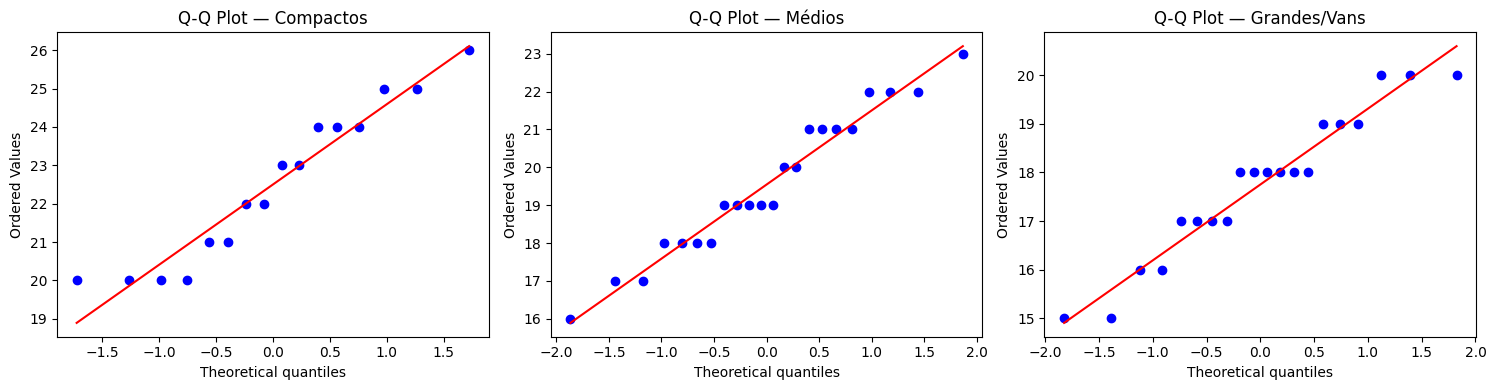

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nome, dados) in zip(axes, grupos_anova.items()):
    stats.probplot(dados, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot — {nome}')
plt.tight_layout()
plt.show()


**Análise:** O teste de Shapiro-Wilk verifica normalidade em cada grupo individualmente.
O teste de Levene avalia se as variâncias são homogêneas entre os grupos, condição
necessária para a ANOVA clássica. Se todas as condições forem satisfeitas (p > 0,05 em
todos), o uso do ANOVA é plenamente justificado.


#### 3.1(ii) — Teste ANOVA one-way (α = 5%)


In [23]:
print("PASSO 1 — Hipóteses")
print("  H0: μ_compactos = μ_médios = μ_grandes  (médias de MPG iguais)")
print("  H1: pelo menos uma média difere das demais")


PASSO 1 — Hipóteses
  H0: μ_compactos = μ_médios = μ_grandes  (médias de MPG iguais)
  H1: pelo menos uma média difere das demais


In [24]:
F_stat, p_anova = f_oneway(compactos, medios, grandes)
k  = 3
N  = len(compactos) + len(medios) + len(grandes)
gl_entre  = k - 1
gl_dentro = N - k

print("PASSO 2 — Estatística de teste  (F de Fisher)")
print(f"  F observado          = {F_stat:.4f}")
print(f"  g.l. entre grupos    = {gl_entre}")
print(f"  g.l. dentro grupos   = {gl_dentro}")


PASSO 2 — Estatística de teste  (F de Fisher)
  F observado          = 30.6432
  g.l. entre grupos    = 2
  g.l. dentro grupos   = 55


In [25]:
alpha     = 0.05
F_critico = stats.f.ppf(1 - alpha, dfn=gl_entre, dfd=gl_dentro)

print("PASSO 3 — Valor crítico e p-valor")
print(f"  α            = {alpha}")
print(f"  F crítico    = {F_critico:.4f}")
print(f"  p-valor      = {p_anova:.6f}")


PASSO 3 — Valor crítico e p-valor
  α            = 0.05
  F crítico    = 3.1650
  p-valor      = 0.000000


In [26]:
print("PASSO 4 — Conclusão")
if p_anova < alpha:
    print(f"  p-valor ({p_anova:.6f}) < α ({alpha})  →  REJEITA H0")
    print("  Há evidências de que as médias de MPG não são todas iguais entre as categorias.")
else:
    print(f"  p-valor ({p_anova:.6f}) ≥ α ({alpha})  →  NÃO rejeita H0")
    print("  Não há evidências suficientes para rejeitar a igualdade das médias.")


PASSO 4 — Conclusão
  p-valor (0.000000) < α (0.05)  →  REJEITA H0
  Há evidências de que as médias de MPG não são todas iguais entre as categorias.


**Análise:** A estatística F compara a variância *entre* grupos com a variância *dentro* dos
grupos. Uma razão F grande indica que as médias diferem mais do que seria esperado por acaso.
A rejeição de $H_0$ indica que pelo menos uma categoria tem MPG médio diferente das demais,
mas não identifica quais — isso exigiria um teste post-hoc como Tukey HSD.


### 3.2 Situação-problema II



In [27]:
df9 = pd.read_excel('data9.xls', header=None, names=['curso', 'custo'])
df9 = df9[df9['curso'] != 'Cource'].reset_index(drop=True)   # remove cabeçalho original
df9['custo'] = df9['custo'].astype(float)
df9['disciplina'] = df9['curso'].str.extract(r'([A-Za-z]+)')

print(df9)
print()
for disc, grp in df9.groupby('disciplina'):
    print(f"{disc}: n={len(grp)},  média={grp['custo'].mean():.2f},  dp={grp['custo'].std(ddof=1):.2f}")


     curso  custo disciplina
0    MATH1  195.0       MATH
1    MATH2  129.0       MATH
2    MATH3  119.0       MATH
3    MATH4  122.0       MATH
4    MATH5  135.0       MATH
5    MATH6  210.0       MATH
6    MATH7  137.0       MATH
7    MATH8  199.0       MATH
8    MATH9  220.0       MATH
9   MATH10  149.0       MATH
10   COMP1  179.0       COMP
11   COMP2  181.0       COMP
12   COMP3  220.0       COMP
13   COMP4  302.0       COMP
14   COMP5  125.0       COMP
15   COMP6  125.0       COMP
16   COMP7  168.0       COMP
17   COMP8  204.0       COMP
18   COMP9  177.0       COMP
19  COMP10  143.0       COMP
20   CHEM1  105.0       CHEM
21   CHEM2  243.0       CHEM
22   CHEM3  208.0       CHEM
23   CHEM4  176.0       CHEM
24   CHEM5  132.0       CHEM
25   CHEM6  155.0       CHEM
26   CHEM7   97.0       CHEM
27   CHEM8   98.0       CHEM
28   CHEM9  105.0       CHEM
29  CHEM10  148.0       CHEM

CHEM: n=10,  média=146.70,  dp=50.00
COMP: n=10,  média=182.40,  dp=52.26
MATH: n=10,  média=161.50,

In [28]:
alpha = 0.01
grupos_d9 = {d: g['custo'].values for d, g in df9.groupby('disciplina')}

print("=== Normalidade — Shapiro-Wilk ===")
for nome, dados in grupos_d9.items():
    stat, p = shapiro(dados)
    print(f"  {nome:6s}: W = {stat:.4f}, p = {p:.4f}  →  "
          + ("REJEITA H0" if p < alpha else "Não rejeita H0"))

stat_lev, p_lev = levene(*grupos_d9.values())
print(f"\nLevene: stat = {stat_lev:.4f}, p = {p_lev:.4f}  →  "
      + ("REJEITA H0" if p_lev < alpha else "Não rejeita H0"))


=== Normalidade — Shapiro-Wilk ===
  CHEM  : W = 0.8957, p = 0.1963  →  Não rejeita H0
  COMP  : W = 0.8859, p = 0.1523  →  Não rejeita H0
  MATH  : W = 0.8491, p = 0.0567  →  Não rejeita H0

Levene: stat = 0.1034, p = 0.9022  →  Não rejeita H0


In [29]:
print("PASSO 1 — Hipóteses")
print("  H0: μ_CHEM = μ_COMP = μ_MATH  (custos médios iguais)")
print("  H1: pelo menos uma média difere")

F2, p2 = f_oneway(*grupos_d9.values())
k2, N2  = 3, sum(len(v) for v in grupos_d9.values())
gl_e2, gl_d2 = k2-1, N2-k2
F_crit2 = stats.f.ppf(1-alpha, dfn=gl_e2, dfd=gl_d2)

print(f"\nPASSO 2 — F observado = {F2:.4f}  (g.l.: {gl_e2}, {gl_d2})")
print(f"PASSO 3 — F crítico = {F_crit2:.4f},  p-valor = {p2:.6f}")
print(f"\nPASSO 4 — Conclusão:")
if p2 < alpha:
    print(f"  p ({p2:.6f}) < α ({alpha})  →  REJEITA H0")
    print("  Os custos médios NÃO são todos iguais entre as três disciplinas (α = 1%).")
else:
    print(f"  p ({p2:.6f}) ≥ α ({alpha})  →  NÃO rejeita H0")
    print("  Sem evidências de diferença nos custos médios entre as disciplinas (α = 1%).")


PASSO 1 — Hipóteses
  H0: μ_CHEM = μ_COMP = μ_MATH  (custos médios iguais)
  H1: pelo menos uma média difere

PASSO 2 — F observado = 1.4180  (g.l.: 2, 27)
PASSO 3 — F crítico = 5.4881,  p-valor = 0.259654

PASSO 4 — Conclusão:
  p (0.259654) ≥ α (0.01)  →  NÃO rejeita H0
  Sem evidências de diferença nos custos médios entre as disciplinas (α = 1%).


**Análise:** Repetem-se os quatro passos do ANOVA one-way agora com $\alpha = 1\%$, um
critério mais conservador que exige evidências mais fortes para rejeitar $H_0$. Se
$F_{\text{obs}} > F_{\text{crítico}}$ (equivalentemente, $p < 0{,}01$), há evidências de que
os custos médios diferem entre pelo menos duas das três disciplinas.


---
## 4. Testes Qui-quadrado

Conjunto de dados `treatment`


In [30]:
url_treat = 'https://raw.githubusercontent.com/selva86/datasets/master/treatment.csv'
df_treat  = pd.read_csv(url_treat)
print(df_treat.head())
print(f"\nShape: {df_treat.shape}")
print(df_treat['treatment'].value_counts())
print(df_treat['improvement'].value_counts())


   id    treatment   improvement
0   1      treated      improved
1   2      treated      improved
2   3  not-treated      improved
3   4      treated      improved
4   5      treated  not-improved

Shape: (105, 3)
treatment
not-treated    55
treated        50
Name: count, dtype: int64
improvement
improved        61
not-improved    44
Name: count, dtype: int64


In [31]:
# (i) Tabela de contingência observada
tabela = pd.crosstab(df_treat['treatment'], df_treat['improvement'])
print("(i) Tabela de contingência observada:")
print(tabela)


(i) Tabela de contingência observada:
improvement  improved  not-improved
treatment                          
not-treated        26            29
treated            35            15


In [32]:
# (ii) Hipóteses
print("(ii) Hipóteses:")
print("  H0: 'treatment' e 'improvement' são independentes")
print("  H1: existe associação entre 'treatment' e 'improvement'")


(ii) Hipóteses:
  H0: 'treatment' e 'improvement' são independentes
  H1: existe associação entre 'treatment' e 'improvement'


In [33]:
# (iii) – (v) Estatística, g.l. e p-valor
chi2_stat, p_val, dof, expected = chi2_contingency(tabela, correction=False)

print(f"(iii) Estatística qui-quadrado : χ² = {chi2_stat:.4f}")
print(f"(iv)  Graus de liberdade       : {dof}")
print(f"(v)   p-valor                  : {p_val:.4f}")
print()
print("Frequências esperadas:")
print(pd.DataFrame(expected, index=tabela.index, columns=tabela.columns).round(2))


(iii) Estatística qui-quadrado : χ² = 5.5569
(iv)  Graus de liberdade       : 1
(v)   p-valor                  : 0.0184

Frequências esperadas:
improvement  improved  not-improved
treatment                          
not-treated     31.95         23.05
treated         29.05         20.95


In [34]:
# (vi) Conclusão
alpha     = 0.05
chi2_crit = chi2.ppf(1 - alpha, df=dof)

print("(vi) Conclusão:")
print(f"  χ² crítico (α={alpha}, g.l.={dof}) = {chi2_crit:.4f}")
print(f"  χ² observado                       = {chi2_stat:.4f}")
if p_val < alpha:
    print(f"  p-valor ({p_val:.4f}) < α ({alpha})  →  REJEITA H0")
    print("  Há evidências de associação entre o tratamento e a melhora do paciente.")
else:
    print(f"  p-valor ({p_val:.4f}) ≥ α ({alpha})  →  NÃO rejeita H0")
    print("  Não há evidências suficientes de associação entre as variáveis.")


(vi) Conclusão:
  χ² crítico (α=0.05, g.l.=1) = 3.8415
  χ² observado                       = 5.5569
  p-valor (0.0184) < α (0.05)  →  REJEITA H0
  Há evidências de associação entre o tratamento e a melhora do paciente.


**Análise:** O teste qui-quadrado de independência verifica se a distribuição de melhora é a
mesma nos grupos tratado e controle. A estatística $\chi^2$ mede o afastamento entre as
frequências observadas e as esperadas sob independência. Antes de interpretar o resultado,
é importante verificar que todas as frequências esperadas são $\geq 5$, o que garante a
validade da aproximação qui-quadrado. Se rejeitarmos $H_0$, concluímos que o medicamento
está associado à melhora — embora o teste não implique causalidade.
